# 01 — Dataset Exploration
**Project:** Rumor / Fake News Detection on Social Media  
**Dataset:** FakeNewsNet (Kaggle — mdepak)  

---

This notebook is the first contact with the data.  
The goal is **not** to build anything — it is to understand what we are working with before writing a single line of model code.  

We will go through:
1. Loading the four CSV files and assigning labels
2. Inspecting columns, types, and missing values
3. Class distribution — are the classes balanced?
4. Source distribution — BuzzFeed vs PolitiFact
5. Text length analysis
6. Word clouds — fake vs real
7. Key takeaways that will drive preprocessing decisions

## 0 — Imports

In [1]:
import os
import sys

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud

# Make sure we can import config.py from the project root
sys.path.append(os.path.join(os.getcwd(), ".."))
import config

# ── Notebook display settings ─────────────────────────────────────────────────
pd.set_option("display.max_columns",  None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.2f}".format)

plt.rcParams.update({
    "figure.dpi":      120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

SEED = config.RANDOM_SEED
print("Config loaded successfully.")
print(f"Raw data folder : {config.DATA_RAW_DIR}")

Config loaded successfully.
Raw data folder : c:\Users\Lenovo\Desktop\projet_deep_l\data\raw


---
## 1 — Load the Four CSV Files

The dataset has no label column inside the files.  
We assign labels based on the filename:
- `*_fake_*` → **0** (fake news)
- `*_real_*` → **1** (real news)

We also add a `source` column to track BuzzFeed vs PolitiFact.

In [2]:
frames = []

for key, filename in config.RAW_FILES.items():
    filepath = os.path.join(config.DATA_RAW_DIR, filename)

    if not os.path.exists(filepath):
        print(f"[WARNING] File not found: {filepath}")
        continue

    df_temp = pd.read_csv(filepath)

    # Assign label and source from config dictionaries
    df_temp[config.LABEL_COLUMN]  = config.FILE_LABELS[key]
    df_temp[config.SOURCE_COLUMN] = config.FILE_SOURCES[key]

    frames.append(df_temp)
    print(f"Loaded  {filename:<45}  shape: {df_temp.shape}")

# Merge all four into one dataframe and reset the index
df = pd.concat(frames, ignore_index=True)
print(f"\nFull dataset shape: {df.shape}")

Loaded  BuzzFeed_fake_news_content.csv                 shape: (91, 13)
Loaded  BuzzFeed_real_news_content.csv                 shape: (91, 13)
Loaded  PolitiFact_fake_news_content.csv               shape: (120, 13)
Loaded  PolitiFact_real_news_content.csv               shape: (120, 13)

Full dataset shape: (422, 13)


---
## 2 — First Look at the Data

In [3]:
# ── Column names and types ────────────────────────────────────────────────────
print("Columns and dtypes:")
print(df.dtypes)
print()

Columns and dtypes:
id                object
title             object
text              object
url               object
top_img           object
authors           object
source            object
publish_date      object
movies            object
images            object
canonical_link    object
meta_data         object
label              int64
dtype: object



In [4]:
# ── First few rows ────────────────────────────────────────────────────────────
df.head(3)

,id,title,text,url,top_img,authors,source,publish_date,movies,images,canonical_link,meta_data,label
0,Fake_1-Webpage,Proof The Mainstream Media Is Manipulating The Election By Taking Bill Clinton Out Of Context,I woke up this morning to find a variation of this headline splashed all over my news feed:\n\nBill Clinton: ‘Natura...,http://www.addictinginfo.org/2016/09/19/proof-the-mainstream-media-is-manipulating-the-election-by-taking-bill-clint...,http://addictinginfo.addictinginfoent.netdna-cdn.com/wp-content/uploads/2016/09/GettyImages-605695152.jpg,Wendy Gittleson,buzzfeed,{'$date': 1474243200000},NaN,"http://i.imgur.com/JeqZLhj.png,http://addictinginfo.addictinginfoent.netdna-cdn.com/wp-content/uploads/2016/09/Scree...",http://addictinginfo.com/2016/09/19/proof-the-mainstream-media-is-manipulating-the-election-by-taking-bill-clinton-o...,"{""publisher"": ""Addicting Info | The Knowledge You Crave"", ""description"": ""These headlines are really damning, unless...",0
1,Fake_10-Webpage,Charity: Clinton Foundation Distributed “Watered-Down” AIDS Drugs to Sub-Saharan Africa – Eagle Rising,Former President Bill Clinton and his Clinton Health Access Initiative (CHAI) distributed “watered-down” HIV/AIDs dr...,http://eaglerising.com/36899/charity-clinton-foundation-distributed-watered-down-aids-drugs-to-sub-saharan-africa/,http://eaglerising.com/wp-content/uploads/2016/09/aids.jpg,View All Posts,buzzfeed,{'$date': 1474416521000},NaN,"http://constitution.com/wp-content/uploads/2017/08/confederatemonument_poll_pop.jpg,http://2lv0hm3wvpix464wwy2zh7d1....",http://eaglerising.com/36899/charity-clinton-foundation-distributed-watered-down-aids-drugs-to-sub-saharan-africa/,"{""description"": ""The possibility that CHAI distributed adulterated and diluted AIDS drugs to Third World victims cou...",0
2,Fake_11-Webpage,A Hillary Clinton Administration May be Entirely Run by a FIGUREHEAD – Eagle Rising,After collapsing just before trying to step into her van after being removed from the 9-11 ceremony in New York City...,http://eaglerising.com/36880/a-hillary-clinton-administration-may-be-entirely-run-by-a-figurehead/,http://eaglerising.com/wp-content/uploads/2016/09/administration.jpg,"View All Posts,Tony Elliott",buzzfeed,{'$date': 1474416638000},NaN,"http://constitution.com/wp-content/uploads/2017/08/confederatemonument_poll_pop.jpg,http://2lv0hm3wvpix464wwy2zh7d1....",http://eaglerising.com/36880/a-hillary-clinton-administration-may-be-entirely-run-by-a-figurehead/,"{""description"": ""Hillary Clinton may be the first Administration in US history where she is only a figurehead, or an...",0


In [5]:
# ── Basic statistics on numeric columns ───────────────────────────────────────
df.describe()

,label
count,422.00
mean,0.50
std,0.50
min,0.00
25%,0.00
50%,0.50
75%,1.00
max,1.00


---
## 3 — Missing Values

We need to understand how much data is actually usable.  
If `text` is often empty, we may have to rely mostly on `title`.

                missing_count  missing_%
movies                    383      90.76
publish_date              127      30.09
authors                    67      15.88
canonical_link             22       5.21
top_img                    14       3.32
images                     14       3.32
url                        12       2.84
id                          0       0.00
text                        0       0.00
title                       0       0.00
source                      0       0.00
meta_data                   0       0.00
label                       0       0.00


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6644\2353698675.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


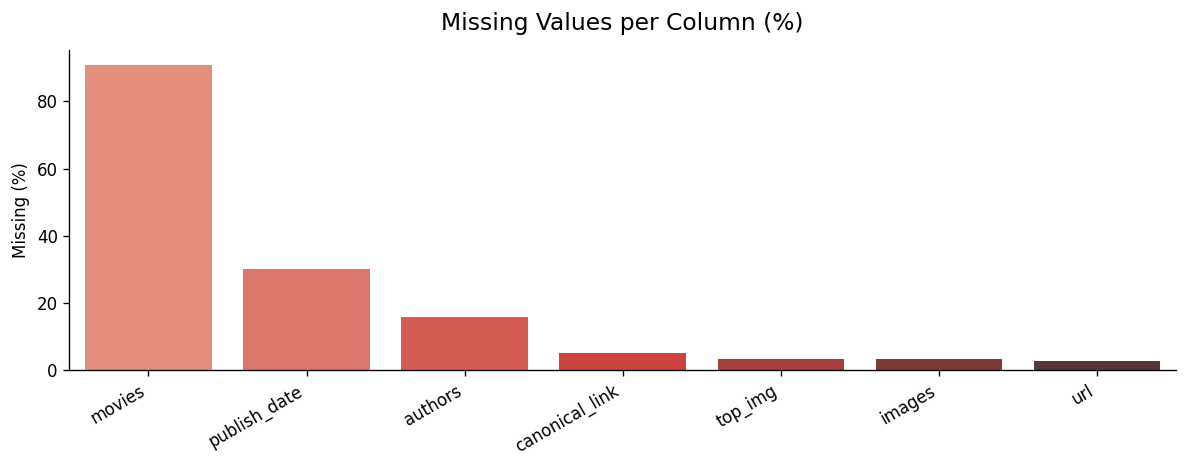

In [6]:
# Count and percentage of missing values per column
missing_count  = df.isnull().sum()
missing_pct    = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "missing_count": missing_count,
    "missing_%":     missing_pct
}).sort_values("missing_%", ascending=False)

print(missing_df)

# ── Visual ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
cols_with_missing = missing_df[missing_df["missing_%"] > 0]

if cols_with_missing.empty:
    ax.text(0.5, 0.5, "No missing values found!",
            ha="center", va="center", fontsize=14, color="green")
    ax.axis("off")
else:
    sns.barplot(
        x=cols_with_missing.index,
        y=cols_with_missing["missing_%"],
        palette="Reds_d", ax=ax
    )
    ax.set_title("Missing Values per Column (%)", fontsize=14, pad=12)
    ax.set_ylabel("Missing (%)")
    ax.set_xlabel("")
    plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, "missing_values.png"), dpi=150)
plt.show()

---
## 4 — Class Distribution

Checking if the dataset is balanced.  
Class imbalance would force us to use weighted loss or oversampling.

Label distribution:
    Fake  (0)  →   211 samples  (50.0%)
    Real  (1)  →   211 samples  (50.0%)


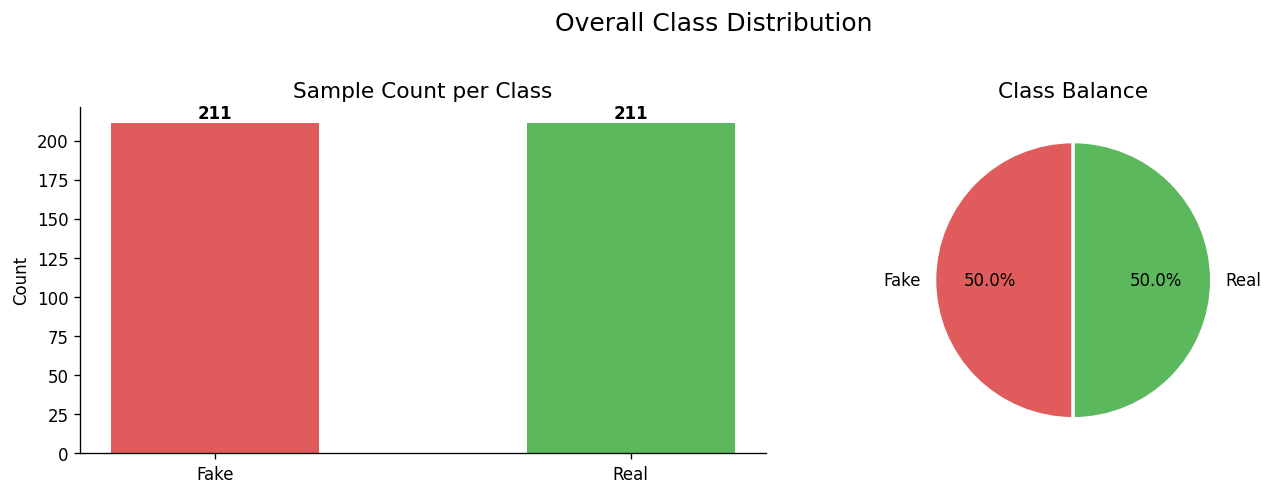

In [7]:
label_counts = df[config.LABEL_COLUMN].value_counts().sort_index()
label_names  = [config.LABEL_NAMES[i] for i in label_counts.index]

print("Label distribution:")
for idx, count in zip(label_counts.index, label_counts.values):
    pct = count / len(df) * 100
    print(f"  {config.LABEL_NAMES[idx]:>6}  ({idx})  →  {count:>4} samples  ({pct:.1f}%)")

# ── Bar + Pie side-by-side ────────────────────────────────────────────────────
colors = ["#e05c5c", "#5cb85c"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(label_names, label_counts.values, color=colors, width=0.5)
axes[0].set_title("Sample Count per Class", fontsize=13)
axes[0].set_ylabel("Count")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 3, str(v), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=label_names,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Class Balance", fontsize=13)

plt.suptitle("Overall Class Distribution", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, "class_distribution.png"), dpi=150)
plt.show()

---
## 5 — Source Distribution

BuzzFeed and PolitiFact may have very different characteristics.  
We check the class balance **within each source** — if one source is heavily skewed,
we will need to stratify our train/test splits by source.

            Fake  Real  Total
source                       
buzzfeed      91    91    182
politifact   120   120    240
All          211   211    422


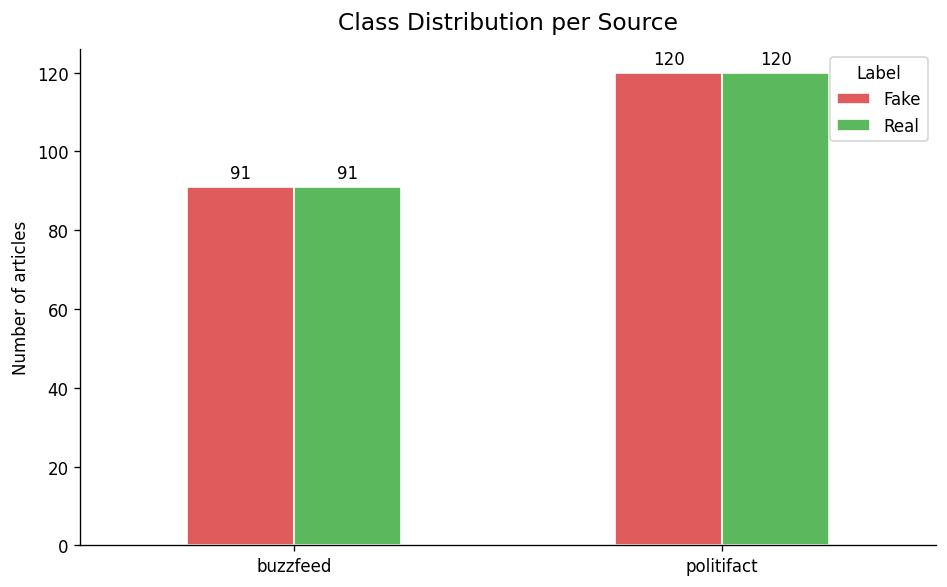

In [8]:
# Cross-tabulation: source × label
cross = pd.crosstab(
    df[config.SOURCE_COLUMN],
    df[config.LABEL_COLUMN],
    margins=True
)
cross.columns = [config.LABEL_NAMES.get(c, "Total") for c in cross.columns]
print(cross)

# ── Grouped bar chart ─────────────────────────────────────────────────────────
source_label = df.groupby(
    [config.SOURCE_COLUMN, config.LABEL_COLUMN]
).size().unstack(fill_value=0)

source_label.columns = [config.LABEL_NAMES[c] for c in source_label.columns]

ax = source_label.plot(
    kind="bar",
    color=colors,
    figsize=(8, 5),
    width=0.5,
    edgecolor="white"
)
ax.set_title("Class Distribution per Source", fontsize=14, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Number of articles")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Label")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, "source_distribution.png"), dpi=150)
plt.show()

---
## 6 — Text Length Analysis

We look at how long the articles are — both by word count and character count.  
This will directly inform the `MAX_SEQUENCE_LENGTH` setting in `config.py`.

In [9]:
# ── Compute length features ───────────────────────────────────────────────────

# Use .fillna("") so missing values do not crash .split()
df["title_word_count"] = df[config.TITLE_COLUMN].fillna("").apply(lambda x: len(x.split()))
df["text_word_count"]  = df[config.TEXT_COLUMN].fillna("").apply(lambda x: len(x.split()))
df["text_char_count"]  = df[config.TEXT_COLUMN].fillna("").apply(len)

print("Title word count:")
print(df["title_word_count"].describe(), "\n")

print("Body text word count:")
print(df["text_word_count"].describe(), "\n")

print("Body text character count:")
print(df["text_char_count"].describe())

Title word count:
count   422.00
mean     10.88
std       3.65
min       3.00
25%       8.00
50%      10.00
75%      13.00
max      29.00
Name: title_word_count, dtype: float64 

Body text word count:
count    422.00
mean     593.80
std      679.60
min        5.00
25%      269.00
50%      394.00
75%      585.00
max     5459.00
Name: text_word_count, dtype: float64 

Body text character count:
count     422.00
mean     3576.66
std      4152.19
min        31.00
25%      1628.00
50%      2295.00
75%      3513.00
max     32493.00
Name: text_char_count, dtype: float64


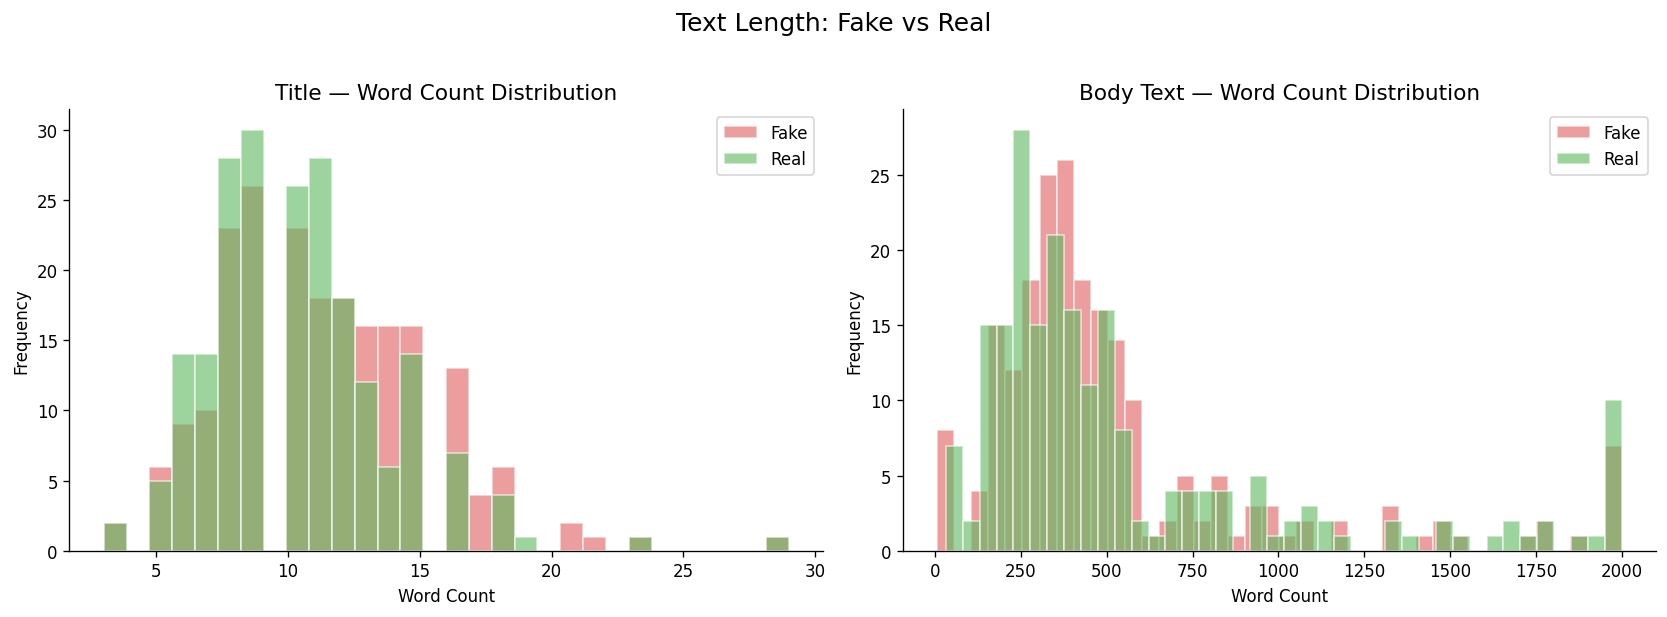

In [10]:
# ── Distribution of word counts — fake vs real ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_color_map = {0: "#e05c5c", 1: "#5cb85c"}

for label_val, label_name in config.LABEL_NAMES.items():
    subset = df[df[config.LABEL_COLUMN] == label_val]
    color  = label_color_map[label_val]

    # Title lengths
    axes[0].hist(
        subset["title_word_count"],
        bins=30, alpha=0.6,
        label=label_name, color=color, edgecolor="white"
    )

    # Body text lengths
    axes[1].hist(
        subset["text_word_count"].clip(upper=2000),
        bins=40, alpha=0.6,
        label=label_name, color=color, edgecolor="white"
    )

axes[0].set_title("Title — Word Count Distribution",     fontsize=13)
axes[1].set_title("Body Text — Word Count Distribution", fontsize=13)

for ax in axes:
    ax.set_xlabel("Word Count")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.suptitle("Text Length: Fake vs Real", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, "text_length_distribution.png"), dpi=150)
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6644\1896790755.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6644\1896790755.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


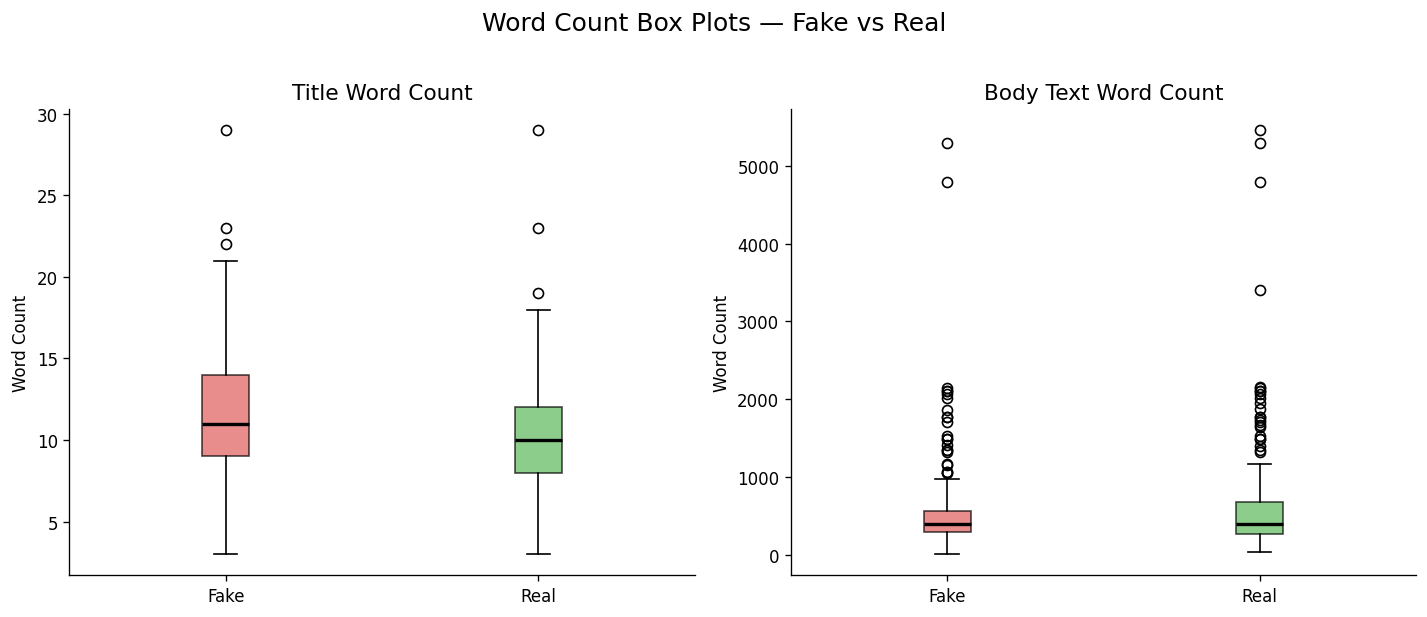

In [11]:
# ── Box plots: word count by class ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(
    axes,
    ["title_word_count", "text_word_count"],
    ["Title Word Count",  "Body Text Word Count"]
):
    data_by_class = [
        df[df[config.LABEL_COLUMN] == label_val][col].dropna().values
        for label_val in sorted(config.LABEL_NAMES.keys())
    ]

    bp = ax.boxplot(
        data_by_class,
        labels=list(config.LABEL_NAMES.values()),
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 2}
    )
    for patch, color in zip(bp["boxes"], ["#e05c5c", "#5cb85c"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(title, fontsize=13)
    ax.set_ylabel("Word Count")

plt.suptitle("Word Count Box Plots — Fake vs Real", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, "word_count_boxplots.png"), dpi=150)
plt.show()

---
## 7 — Word Clouds

A quick visual of the most frequent words in fake vs real articles.  
We look at **titles only** here (cleaner signal than full body text).  
This will give us a first idea of what vocabulary is distinctive for each class.

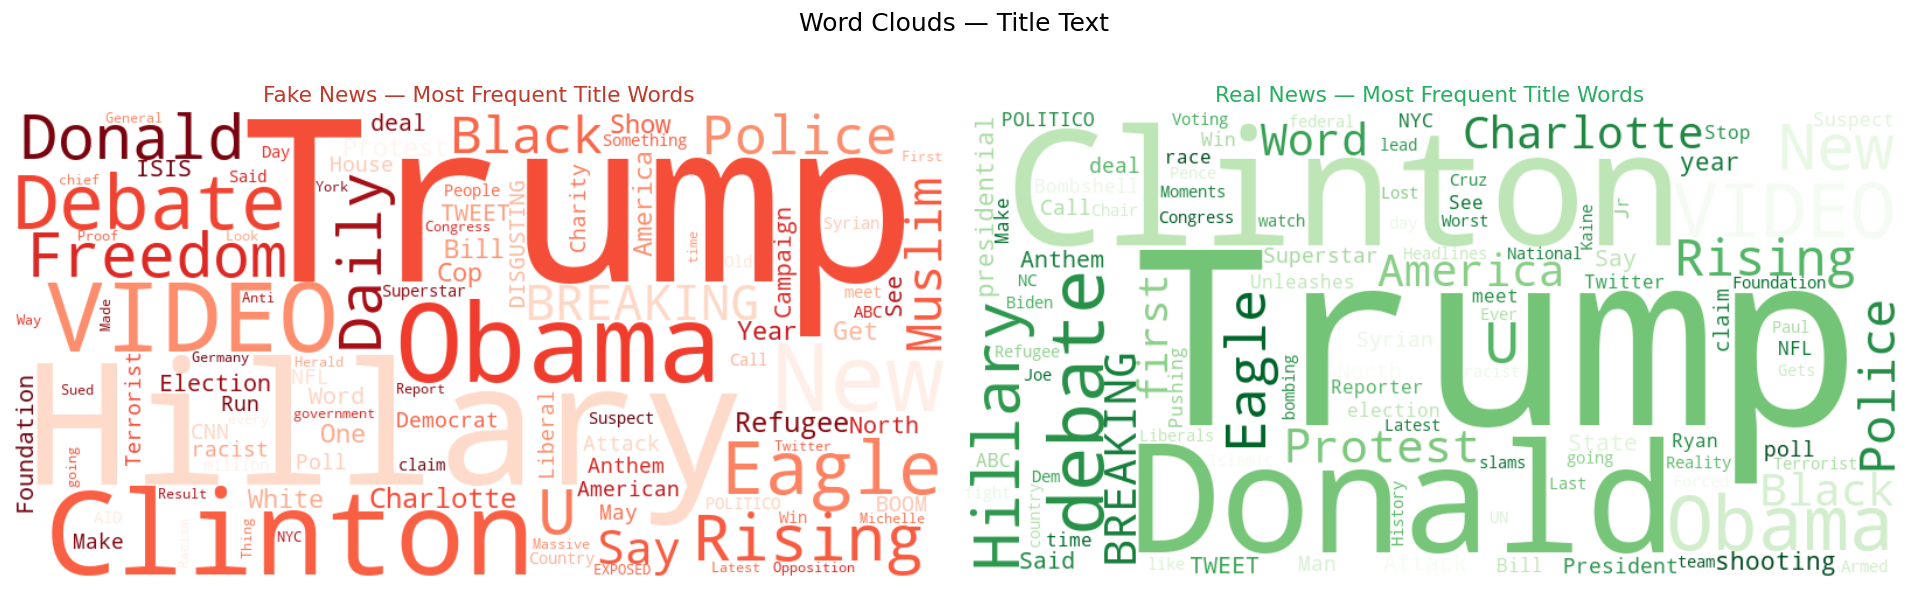

In [13]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)
STOP_WORDS = set(stopwords.words("english"))

def build_corpus(dataframe, label_val, column):
    """Concatenate all text for a given label into a single string."""
    subset = dataframe[dataframe[config.LABEL_COLUMN] == label_val][column]
    return " ".join(subset.dropna().values)


fake_title_corpus = build_corpus(df, label_val=0, column=config.TITLE_COLUMN)
real_title_corpus = build_corpus(df, label_val=1, column=config.TITLE_COLUMN)

wc_settings = dict(
    width=800,
    height=400,
    background_color="white",
    stopwords=STOP_WORDS,
    max_words=100,
    collocations=False,
)

wc_fake = WordCloud(**wc_settings, colormap="Reds" ).generate(fake_title_corpus)
wc_real = WordCloud(**wc_settings, colormap="Greens").generate(real_title_corpus)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(wc_fake, interpolation="bilinear")
axes[0].set_title("Fake News — Most Frequent Title Words", fontsize=13, color="#c0392b")
axes[0].axis("off")

axes[1].imshow(wc_real, interpolation="bilinear")
axes[1].set_title("Real News — Most Frequent Title Words", fontsize=13, color="#27ae60")
axes[1].axis("off")

plt.suptitle("Word Clouds — Title Text", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, "wordclouds_title.png"), dpi=150)
plt.show()

---
## 8 — Top N-Grams

Word clouds are good visually but miss context.  
We look at the most frequent **unigrams and bigrams** for each class to see if there are clear linguistic patterns.

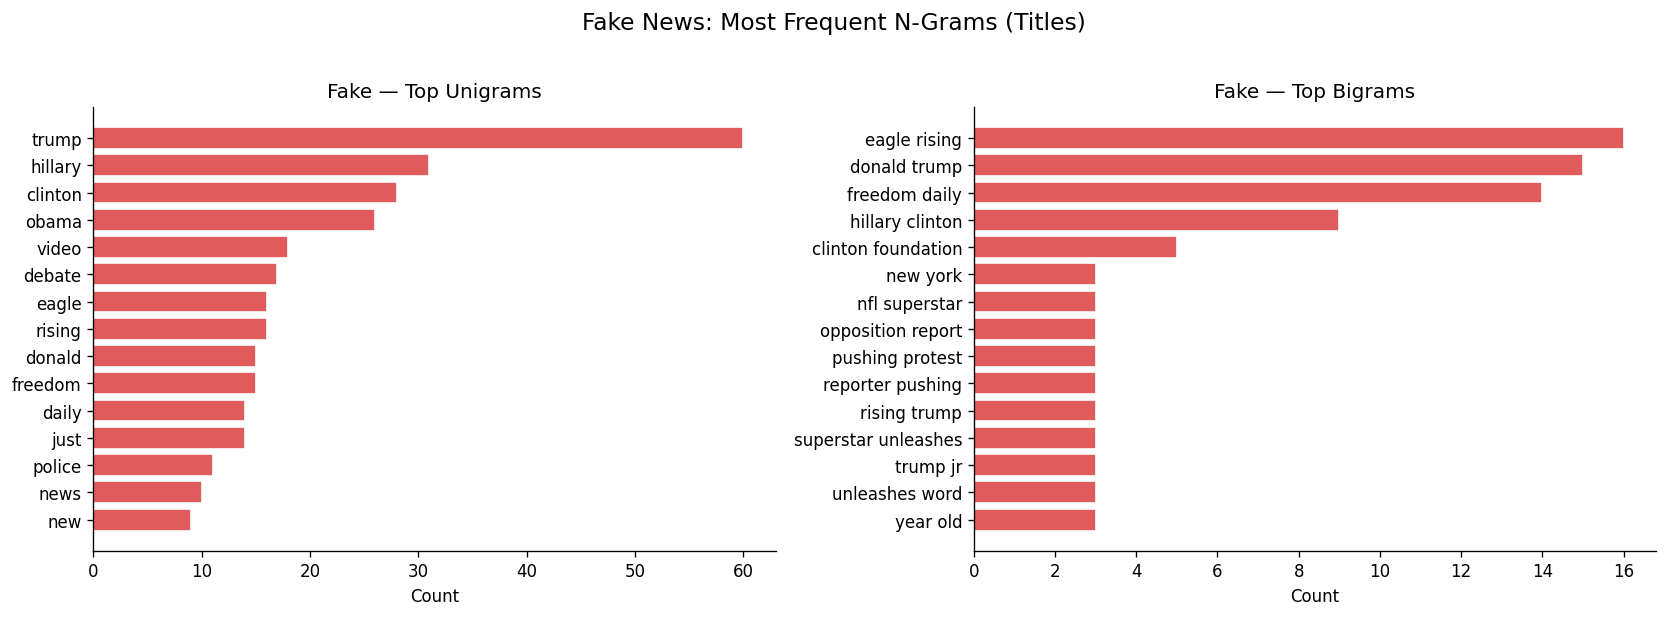

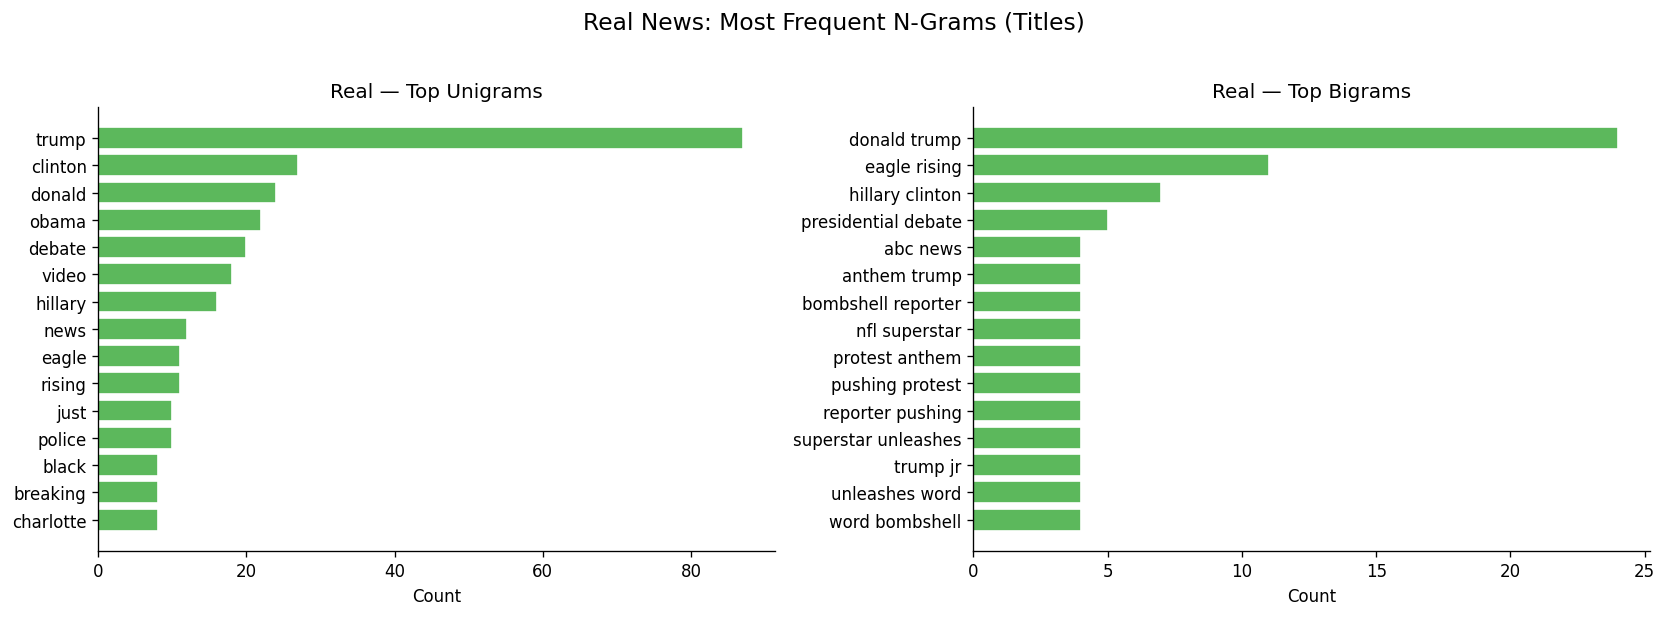

In [14]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=2, top_k=15):
    """
    Extract the top_k most frequent n-grams from a corpus string.

    Parameters
    ----------
    corpus : str
        The full text corpus (all documents joined).
    n : int
        Size of the n-gram (1 = unigram, 2 = bigram).
    top_k : int
        Number of top n-grams to return.

    Returns
    -------
    list of (str, int): sorted list of (ngram, count) tuples.
    """
    vec = CountVectorizer(
        ngram_range=(n, n),
        stop_words="english",
        max_features=top_k
    ).fit([corpus])
    bag = vec.transform([corpus])
    counts = zip(vec.get_feature_names_out(), bag.toarray()[0])
    return sorted(counts, key=lambda x: x[1], reverse=True)


for label_val, label_name, color in zip([0, 1], ["Fake", "Real"], ["#e05c5c", "#5cb85c"]):
    corpus = build_corpus(df, label_val=label_val, column=config.TITLE_COLUMN)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, n, ngram_label in zip(axes, [1, 2], ["Unigrams", "Bigrams"]):
        top = get_top_ngrams(corpus, n=n, top_k=15)
        words, counts = zip(*top)

        ax.barh(words, counts, color=color, edgecolor="white")
        ax.invert_yaxis()
        ax.set_title(f"{label_name} — Top {ngram_label}", fontsize=12)
        ax.set_xlabel("Count")

    plt.suptitle(f"{label_name} News: Most Frequent N-Grams (Titles)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(
        os.path.join(config.RESULTS_DIR, f"ngrams_{label_name.lower()}.png"),
        dpi=150
    )
    plt.show()

---
## 9 — Sample Rows

Always look at actual examples before preprocessing.  
This gives intuition that no chart can replace.

In [15]:
print("=" * 80)
print("FAKE NEWS SAMPLES")
print("=" * 80)
fake_samples = df[df[config.LABEL_COLUMN] == 0][[config.TITLE_COLUMN, config.TEXT_COLUMN, config.SOURCE_COLUMN]].sample(3, random_state=SEED)
for i, (_, row) in enumerate(fake_samples.iterrows(), 1):
    print(f"\n[{i}] Source: {row[config.SOURCE_COLUMN]}")
    print(f"    Title: {row[config.TITLE_COLUMN]}")
    body_preview = str(row[config.TEXT_COLUMN])[:300].replace("\n", " ")
    print(f"    Body : {body_preview}...")

print("\n" + "=" * 80)
print("REAL NEWS SAMPLES")
print("=" * 80)
real_samples = df[df[config.LABEL_COLUMN] == 1][[config.TITLE_COLUMN, config.TEXT_COLUMN, config.SOURCE_COLUMN]].sample(3, random_state=SEED)
for i, (_, row) in enumerate(real_samples.iterrows(), 1):
    print(f"\n[{i}] Source: {row[config.SOURCE_COLUMN]}")
    print(f"    Title: {row[config.TITLE_COLUMN]}")
    body_preview = str(row[config.TEXT_COLUMN])[:300].replace("\n", " ")
    print(f"    Body : {body_preview}...")

FAKE NEWS SAMPLES

[1] Source: buzzfeed
    Title: DESPICABLE! Hillary Wants To Put Hero Cop Who Stopped Mall Terror Attack Out Of BUSINESS ⋆ Freedom Daily
    Body : 5.2k SHARES Facebook Twitter  Jason Falconer, the NRA-certified firearms instructor and off-duty police officer, who shot the ISIS terrorist who stabbed eight people in St. Cloud, Minnesota, is someone that Hillary Clinton wants to put out of business. In fact, it’s one of the primary things she int...

[2] Source: politifact
    Title: Debate breaks record as most-watched in U.S. history
    Body : Monday night was the most-watched debate in American history.  Well over 80 million people tuned in to see Hillary Clinton and Donald Trump face off, setting a new record in the sixty year history of televised presidential debates.  According to Nielsen, the debate averaged a total of 84 million vie...

[3] Source: politifact
    Title: BREAKING: Toby Keith Forced To Cancel Show, I Didn’t Expect This
    Body : Toby Keith has 

---
## 10 — Duplicate Check

In [16]:
# Check for exact duplicate rows
n_duplicates = df.duplicated().sum()
print(f"Exact duplicate rows   : {n_duplicates}")

# Check for duplicate titles (different bodies, same title)
n_dup_titles = df[config.TITLE_COLUMN].duplicated().sum()
print(f"Duplicate titles       : {n_dup_titles}")

# Check for duplicate body text
n_dup_text = df[config.TEXT_COLUMN].dropna().duplicated().sum()
print(f"Duplicate body texts   : {n_dup_text}")

Exact duplicate rows   : 0
Duplicate titles       : 133
Duplicate body texts   : 133


---
## 11 — Key Takeaways

After running all cells above, fill in the findings here.  
These observations will directly inform the decisions made in `src/preprocess.py`.

| Question | Observation |
|---|---|
| Are classes balanced? | *(fill after running)* |
| Is `text` often missing? | *(fill after running)* |
| Typical text length (words)? | *(fill after running)* |
| Should we use title only, text only, or both? | *(fill after running)* |
| Is BuzzFeed and PolitiFact similarly distributed? | *(fill after running)* |
| Are there duplicates to remove? | *(fill after running)* |
| Does `MAX_SEQUENCE_LENGTH = 256` make sense? | *(fill after running)* |

---

**Next step:** `notebooks/02_experiments.ipynb` — test preprocessing ideas before writing `src/preprocess.py`.